In [ ]:
pip install emoji vncorenlp

In [ ]:
import html
import inspect
import random
import re
import unicodedata
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Sequence
from urllib.request import urlretrieve

import emoji
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from vncorenlp import VnCoreNLP


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Config

In [ ]:
run_name = "hosrev-e5-small"
dataset_dir = Path("/content/drive/MyDrive/bachnt/KHDL/hosrev/")
train_csv_path = dataset_dir / "train.csv"
val_csv_path = dataset_dir / "validation.csv"
test_csv_path = dataset_dir / "test.csv"
pretrained_model_name = "intfloat/multilingual-e5-small"


In [ ]:
epochs = 20
batch_size = 21
max_length = 256
learning_rate = 2e-4
weight_decay = 0.0
warmup_ratio = 0.1
early_stopping_patience = 7
early_stopping_min_delta = 0.0
num_workers = 0
multi_branch = False
use_text_preprocessing = True
seed = 42

training_dir = Path("training") if Path("training").exists() else Path(".")
output_dir = Path("/content/drive/MyDrive/bachnt/KHDL/checkpoints")
prediction_dir = Path("/content/drive/MyDrive/bachnt/KHDL/predictions")


# Preprocess

## Label Mapping


In [ ]:
class PolarityMapping:
    INDEX_TO_POLARITY = {0: None, 1: "positive", 2: "negative", 3: "neutral"}
    POLARITY_TO_INDEX = {None: 0, "positive": 1, "negative": 2, "neutral": 3}


##  Word Segmentation


In [ ]:
VNCORENLP_BASE_URL = "https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master"
VNCORENLP_FILES = [
    "VnCoreNLP-1.2.jar",
    "models/wordsegmenter/vi-vocab",
    "models/wordsegmenter/wordsegmenter.rdr",
]
WORD_SEGMENTER: VnCoreNLP | None = None


def ensure_vncorenlp(vncorenlp_dir: str | Path = "VnCoreNLP") -> Path:
    vncorenlp_dir = Path(vncorenlp_dir)
    for relative_path in VNCORENLP_FILES:
        local_path = vncorenlp_dir / relative_path
        if local_path.exists():
            continue
        local_path.parent.mkdir(parents=True, exist_ok=True)
        url = f"{VNCORENLP_BASE_URL}/{relative_path}"
        print(f"Downloading {url} -> {local_path}")
        urlretrieve(url, local_path)
    return vncorenlp_dir


def get_word_segmenter() -> VnCoreNLP:
    global WORD_SEGMENTER
    if WORD_SEGMENTER is None:
        vncorenlp_dir = ensure_vncorenlp()
        WORD_SEGMENTER = VnCoreNLP(
            str(vncorenlp_dir / "VnCoreNLP-1.2.jar"),
            annotators="wseg",
            quiet=True,
        )
    return WORD_SEGMENTER


## Text Cleaning


In [ ]:
TEENCODE_URL = "https://raw.githubusercontent.com/NeoCyber05/Aspect_Based_Sentiment_Analysis_for_Place_Reviews/main/training/teencode/hosRev_teencode.txt"
ACRONYM_MAP: dict[str, str] | None = None


def build_acronym_map(teencode_path: str | Path = "teencode.txt") -> dict[str, str]:
    teencode_path = Path(teencode_path)
    print(f"Downloading {TEENCODE_URL} -> {teencode_path}")
    urlretrieve(TEENCODE_URL, teencode_path)
    mapping: dict[str, str] = {}
    for line in teencode_path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        if "\t" in line:
            teencode, normalized = line.split("\t", 1)
        elif " - " in line:
            teencode, normalized = line.split(" - ", 1)
        else:
            continue
        teencode = teencode.strip().lower()
        normalized = normalized.strip()
        if teencode and normalized:
            mapping[teencode] = normalized
    return mapping


def normalize_acronyms(text: str) -> str:
    global ACRONYM_MAP
    if ACRONYM_MAP is None:
        ACRONYM_MAP = build_acronym_map()
    return " ".join(ACRONYM_MAP.get(word.lower(), word) for word in text.split())


def remove_HTML(text: str) -> str:
    text = html.unescape(str(text))
    return re.sub(r"<[^>]+>", " ", text)


def convert_unicode(text: str) -> str:
    return unicodedata.normalize("NFC", text)


def word_segmentation(text: str) -> str:
    sentences = get_word_segmenter().tokenize(text)
    return " ".join(token for sentence in sentences for token in sentence)


def remove_unnecessary_characters(text: str) -> str:
    text = emoji.replace_emoji(text, " ")
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    return re.sub(r"\s+", " ", text).strip()


def text_preprocess(text: str) -> str:
    text = remove_HTML(text)
    text = convert_unicode(text)
    text = normalize_acronyms(text)
    text = word_segmentation(text)
    return remove_unnecessary_characters(text)


# Dataset


In [ ]:
def infer_aspect_category_names(csv_path: str | Path) -> list[str]:
    columns = pd.read_csv(csv_path, nrows=0).columns.tolist()
    return [column for column in columns if column != "Review"]


class ABSACsvDataset(Dataset):
    def __init__(
        self,
        csv_path: str | Path,
        aspect_category_names: Sequence[str] | None = None,
        text_preprocessor=None,
    ) -> None:
        self.csv_path = Path(csv_path)
        self.frame = pd.read_csv(self.csv_path)
        self.aspect_category_names = list(aspect_category_names or infer_aspect_category_names(self.csv_path))
        self.raw_texts = self.frame["Review"].astype(str).tolist()
        if text_preprocessor is None:
            self.texts = self.raw_texts
        else:
            self.texts = [
                text_preprocessor(text)
                for text in tqdm(self.raw_texts, desc=f"preprocess {self.csv_path.name}", leave=False)
            ]
        self.labels = self.frame[self.aspect_category_names].fillna(0).astype("int64").to_numpy()

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int) -> dict[str, object]:
        return {"text": self.texts[index], "labels": self.labels[index]}


## Collator And Dataloaders


In [ ]:
@dataclass
class ABSACollator:
    tokenizer: object
    max_length: int = 256

    def __call__(self, examples: list[dict[str, object]]) -> dict[str, torch.Tensor]:
        texts = [str(example["text"]) for example in examples]
        labels = torch.tensor(np.stack([example["labels"] for example in examples]), dtype=torch.long)
        encoded = self.tokenizer(
            texts,
            max_length=self.max_length,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )
        encoded["labels"] = labels
        return encoded


def build_dataloaders(
    train_csv_path: str | Path,
    val_csv_path: str | Path,
    test_csv_path: str | Path,
    tokenizer: object,
    batch_size: int = 8,
    max_length: int = 256,
    num_workers: int = 0,
    text_preprocessor=None,
) -> tuple[dict[str, DataLoader], list[str]]:
    paths = {
        "train": Path(train_csv_path),
        "val": Path(val_csv_path),
        "test": Path(test_csv_path),
    }
    aspect_category_names = infer_aspect_category_names(paths["train"])
    collator = ABSACollator(tokenizer=tokenizer, max_length=max_length)
    datasets = {
        split: ABSACsvDataset(
            path,
            aspect_category_names=aspect_category_names,
            text_preprocessor=text_preprocessor,
        )
        for split, path in paths.items()
    }
    loaders = {
        "train": DataLoader(datasets["train"], batch_size=batch_size, shuffle=True, num_workers=num_workers, collate_fn=collator),
        "val": DataLoader(datasets["val"], batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collator),
        "test": DataLoader(datasets["test"], batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collator),
    }
    return loaders, aspect_category_names


# Model

In [ ]:
class TransformerABSA(nn.Module):
    def __init__(
        self,
        pretrained_model_name: str,
        aspect_category_names: Iterable[str],
        multi_branch: bool = False,
        dropout: float = 0.2,
    ) -> None:
        super().__init__()
        self.aspect_category_names = list(aspect_category_names)
        self.multi_branch = multi_branch
        self.transformer = AutoModel.from_pretrained(pretrained_model_name)
        hidden_size = self.transformer.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier_heads = nn.ModuleList([nn.Linear(hidden_size, 4) for _ in self.aspect_category_names])
        self._transformer_forward_args = set(inspect.signature(self.transformer.forward).parameters)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
        token_type_ids: torch.Tensor | None = None,
    ) -> torch.Tensor:
        model_inputs = {"input_ids": input_ids}
        if attention_mask is not None:
            model_inputs["attention_mask"] = attention_mask
        if token_type_ids is not None and "token_type_ids" in self._transformer_forward_args:
            model_inputs["token_type_ids"] = token_type_ids

        outputs = self.transformer(**model_inputs)
        token_embeddings = outputs.last_hidden_state
        if attention_mask is None:
            pooled_output = token_embeddings.mean(dim=1)
        else:
            mask = attention_mask.unsqueeze(-1).type_as(token_embeddings)
            pooled_output = (token_embeddings * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        review_embedding = self.dropout(pooled_output)
        logits_by_aspect = torch.stack([head(review_embedding) for head in self.classifier_heads], dim=1)
        if self.multi_branch:
            return logits_by_aspect
        return logits_by_aspect.reshape(logits_by_aspect.size(0), -1)

    def reshape_logits(self, logits: torch.Tensor) -> torch.Tensor:
        if logits.dim() == 3:
            return logits
        return logits.reshape(logits.size(0), len(self.aspect_category_names), 4)

    @torch.no_grad()
    def acsa_predict(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        self.eval()
        logits = self(**batch)
        logits = self.reshape_logits(logits)
        return logits.argmax(dim=-1)

    def print_acsa_pred(self, y_pred: torch.Tensor) -> None:
        if y_pred.dim() > 1:
            y_pred = y_pred[0]
        for aspect_category, label_index in zip(self.aspect_category_names, y_pred.tolist()):
            polarity = PolarityMapping.INDEX_TO_POLARITY[int(label_index)]
            if polarity:
                print(f"=> {aspect_category},{polarity}")

# Eval

In [ ]:
class ABSASklearnEvaluator:
    def __init__(self, y_test, y_pred, aspect_category_names):
        y_test = np.asarray(y_test)
        y_pred = np.asarray(y_pred)
        aspect_test, aspect_pred = [], []
        aspect_polarity_test, aspect_polarity_pred = [], []

        for row_test, row_pred in zip(y_test, y_pred):
            for index, (col_test, col_pred) in enumerate(zip(row_test, row_pred)):
                aspect_name = aspect_category_names[index]
                aspect_test.append(bool(col_test) * aspect_name)
                aspect_pred.append(bool(col_pred) * aspect_name)
                aspect_polarity_test.append(f"{aspect_name},{PolarityMapping.INDEX_TO_POLARITY[int(col_test)]}")
                aspect_polarity_pred.append(f"{aspect_name},{PolarityMapping.INDEX_TO_POLARITY[int(col_pred)]}")

        self.aspect_category_report = classification_report(
            aspect_test,
            aspect_pred,
            digits=4,
            zero_division=1,
            output_dict=True,
        )
        self.aspect_category_polarity_report = classification_report(
            aspect_polarity_test,
            aspect_polarity_pred,
            digits=4,
            zero_division=1,
            output_dict=True,
        )

    def report(self, report_type: str):
        if report_type == "aspect#category":
            return pd.DataFrame(self.aspect_category_report).T
        if report_type == "aspect#category,polarity":
            return pd.DataFrame(self.aspect_category_polarity_report).T
        raise ValueError('report_type must be "aspect#category" or "aspect#category,polarity"')


# Training

In [ ]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def move_batch_to_device(batch: dict[str, torch.Tensor], device: torch.device) -> dict[str, torch.Tensor]:
    return {key: value.to(device) for key, value in batch.items()}


def model_inputs(batch: dict[str, torch.Tensor]) -> dict[str, torch.Tensor]:
    allowed = {"input_ids", "attention_mask", "token_type_ids"}
    return {key: value for key, value in batch.items() if key in allowed}


def compute_loss(model: TransformerABSA, criterion: nn.Module, batch: dict[str, torch.Tensor]) -> tuple[torch.Tensor, torch.Tensor]:
    labels = batch["labels"]
    logits = model(**model_inputs(batch))
    logits_by_aspect = model.reshape_logits(logits)
    loss = criterion(logits_by_aspect.reshape(-1, 4), labels.reshape(-1))
    return loss, logits_by_aspect


def train_one_epoch(model, dataloader, optimizer, scheduler, criterion, device: torch.device) -> float:
    model.train()
    total_loss = 0.0
    for batch in tqdm(dataloader, desc="train", leave=False):
        batch = move_batch_to_device(batch, device)
        optimizer.zero_grad(set_to_none=True)
        loss, _ = compute_loss(model, criterion, batch)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / max(1, len(dataloader))


@torch.no_grad()
def evaluate(model, dataloader, criterion, device: torch.device) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    all_predictions = []
    all_targets = []

    for batch in tqdm(dataloader, desc="eval", leave=False):
        batch = move_batch_to_device(batch, device)
        loss, logits = compute_loss(model, criterion, batch)
        predictions = logits.argmax(dim=-1)
        labels = batch["labels"]

        total_loss += loss.item()

        # Thu thập dự đoán và nhãn thực tế
        all_predictions.extend(predictions.cpu().numpy().flatten())
        all_targets.extend(labels.cpu().numpy().flatten())

    from sklearn.metrics import f1_score
    # Tính Macro F1 tổng thể cho cả 4 class (0, 1, 2, 3)
    macro_f1 = f1_score(all_targets, all_predictions, average="macro", zero_division=0)

    # Tính accuracy
    correct = sum(p == t for p, t in zip(all_predictions, all_targets))
    accuracy = correct / max(1, len(all_targets))

    return {
        "loss": total_loss / max(1, len(dataloader)),
        "accuracy": accuracy,
        "f1": macro_f1
    }


def save_checkpoint(path: Path, model: TransformerABSA, optimizer: torch.optim.Optimizer, epoch: int, metrics: dict[str, float]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "epoch": epoch,
            "metrics": metrics,
            "pretrained_model_name": pretrained_model_name,
            "aspect_category_names": model.aspect_category_names,
            "multi_branch": model.multi_branch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        },
        path,
    )


def plot_training_history(history: dict[str, list[float]], figsize=(15, 5)) -> None:
    plt.figure(figsize=figsize)
    plt.plot(history["loss"], linestyle="solid", marker="o", color="crimson", label="Train")
    if "val_loss" in history:
        plt.plot(history["val_loss"], linestyle="solid", marker="o", color="dodgerblue", label="Validation")
    plt.xlabel("Epochs", fontsize=14)
    plt.ylabel("Loss", fontsize=14)
    plt.title("Loss", fontsize=15)
    plt.legend(loc="best")
    plt.show()


def save_absa_predictions(save_path: str | Path, raw_texts, encoded_review_labels, aspect_category_names) -> None:
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    with save_path.open("w", encoding="utf-8") as file:
        for index, encoded_label in tqdm(list(enumerate(encoded_review_labels)), desc="write predictions"):
            polarities = [PolarityMapping.INDEX_TO_POLARITY[int(label)] for label in encoded_label]
            annotation_text = ", ".join(
                f"{{{aspect_category}, {polarity}}}"
                for aspect_category, polarity in zip(aspect_category_names, polarities)
                if polarity
            )
            file.write(f"#{index + 1}\n{raw_texts[index]}\n{annotation_text}\n\n")


In [ ]:
set_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

csv_paths = {
    "train": Path(train_csv_path),
    "val": Path(val_csv_path),
    "test": Path(test_csv_path),
}
missing_paths = [path for path in csv_paths.values() if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Missing CSV files. Change train_csv_path, val_csv_path, or test_csv_path.\n"
        + "\n".join(str(path) for path in missing_paths)
    )

for split, path in csv_paths.items():
    print(f"{split}: {path}")

pd.read_csv(csv_paths["train"], nrows=3)

Device: cuda
train: /content/drive/MyDrive/bachnt/KHDL/hosrev/train.csv
val: /content/drive/MyDrive/bachnt/KHDL/hosrev/validation.csv
test: /content/drive/MyDrive/bachnt/KHDL/hosrev/test.csv


,Review,Cơ sở vật chất#Chất lượng,Cơ sở vật chất#Khác,Cơ sở vật chất#Không gian,Cơ sở vật chất#Vệ sinh,Nhân viên y tế#Chất lượng,Nhân viên y tế#Khác,Nhân viên y tế#Thái độ,Trải nghiệm chung#Chất lượng,Trải nghiệm chung#Giá,Trải nghiệm chung#Khác,Trải nghiệm chung#Không gian,Trải nghiệm chung#Thái độ,Trải nghiệm chung#Vệ sinh
0,"Em đang điều trị tại khoa Vi Phẫu, mấy chị điề...",0,0,0,0,0,0,1,0,0,0,0,0,0
1,Tôi thật sự hài lòng với trải nghiệm ở đây!!!,0,0,0,0,0,0,0,0,0,1,0,0,0
2,Chở mẹ tôi đi chích ngừa uốn ván tại đây. Cơ s...,2,0,0,0,0,0,1,0,0,0,0,0,0


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name)

def preprocess_for_model(text: str) -> str:
    return text_preprocess(text)

active_text_preprocessor = preprocess_for_model if use_text_preprocessing else None
print(f"Text preprocessing: {'enabled' if active_text_preprocessor else 'disabled'}")

loaders, aspect_category_names = build_dataloaders(
    train_csv_path=train_csv_path,
    val_csv_path=val_csv_path,
    test_csv_path=test_csv_path,
    tokenizer=tokenizer,
    batch_size=batch_size,
    max_length=max_length,
    num_workers=num_workers,
    text_preprocessor=active_text_preprocessor,
)

print(f"Aspects: {len(aspect_category_names)}")
print(aspect_category_names)
print({split: len(loader.dataset) for split, loader in loaders.items()})
print("Raw sample:", loaders["train"].dataset.raw_texts[0][:250])
print("Model input sample:", loaders["train"].dataset.texts[0][:250])



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

...

Text preprocessing: enabled


preprocess train.csv:   0%|          | 0/4566 [00:00<?, ?it/s]

preprocess validation.csv:   0%|          | 0/978 [00:00<?, ?it/s]

preprocess test.csv:   0%|          | 0/979 [00:00<?, ?it/s]

Aspects: 13
['Cơ sở vật chất#Chất lượng', 'Cơ sở vật chất#Khác', 'Cơ sở vật chất#Không gian', 'Cơ sở vật chất#Vệ sinh', 'Nhân viên y tế#Chất lượng', 'Nhân viên y tế#Khác', 'Nhân viên y tế#Thái độ', 'Trải nghiệm chung#Chất lượng', 'Trải nghiệm chung#Giá', 'Trải nghiệm chung#Khác', 'Trải nghiệm chung#Không gian', 'Trải nghiệm chung#Thái độ', 'Trải nghiệm chung#Vệ sinh']
{'train': 4566, 'val': 978, 'test': 979}
Raw sample: Em đang điều trị tại khoa Vi Phẫu, mấy chị điều dưỡng (chị Tuyền, chị Yến) nhiệt tình, giải thích dễ hiểu, ân cần nữa. Bác sĩ cũng vui vẻ lắm, tạo tâm lí tốt cho em. ❤️
Model input sample: Em đang điều_trị tại khoa Vi_Phẫu mấy chị điều điều_dưỡng chị Tuyền chị Yến nhiệt_tình giải_thích dễ hiểu ân_cần nữa Bác_sĩ cũng vui_vẻ lắm tạo tâm_lí tốt chờ em


In [ ]:
model = TransformerABSA(
    pretrained_model_name=pretrained_model_name,
    aspect_category_names=aspect_category_names,
    multi_branch=multi_branch,
).to(device)

optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

from collections import Counter

# Lấy nhãn từ tập train dataset để tính số lượng mẫu (n_i) của từng lớp
all_labels = loaders["train"].dataset.labels.flatten()
counts = Counter(all_labels.tolist())

beta = 0.99  # Tham số kiểm soát độ phạt
cb_weights = []
for i in range(4):
    n_i = counts.get(i, 1)  # Lấy số mẫu của lớp i (mặc định là 1 nếu lớp đó không có mẫu nào)
    cb_weights.append((1.0 - beta) / (1.0 - (beta ** n_i)))

class_weights = torch.tensor(cb_weights, dtype=torch.float).to(device)
class_weights = class_weights / class_weights.mean()

print("Trọng số Class-Balanced:", class_weights.tolist())
criterion = nn.CrossEntropyLoss(weight=class_weights)

total_steps = len(loaders["train"]) * epochs
warmup_steps = int(total_steps * warmup_ratio)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total train steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Trọng số Class-Balanced: [0.9493926167488098, 0.9493926167488098, 0.9493926167488098, 1.1518223285675049]
Total train steps: 4360
Warmup steps: 436


In [ ]:
history = {"loss": [], "val_loss": [], "val_accuracy": [], "val_f1": []} # Thêm val_f1
best_val_f1 = -1.0
epochs_without_improvement = 0
best_checkpoint_path = output_dir / f"{run_name}-best.pt"
last_checkpoint_path = output_dir / f"{run_name}-last.pt"
for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, loaders["train"], optimizer, scheduler, criterion, device)
    val_metrics = evaluate(model, loaders["val"], criterion, device)
    history["loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["val_f1"].append(val_metrics["f1"])
    print(
        f"epoch={epoch} "
        f"train_loss={train_loss:.4f} "
        f"val_loss={val_metrics['loss']:.4f} "
        f"val_accuracy={val_metrics['accuracy']:.4f} "
        f"val_f1={val_metrics['f1']:.4f}"
    )
    save_checkpoint(last_checkpoint_path, model, optimizer, epoch, val_metrics)

    #Lưu checkpoint tốt nhất theo F1
    if val_metrics["f1"] > best_val_f1 + early_stopping_min_delta:
        best_val_f1 = val_metrics["f1"]
        epochs_without_improvement = 0
        save_checkpoint(best_checkpoint_path, model, optimizer, epoch, val_metrics)
        print(f"Saved best checkpoint (F1): {best_checkpoint_path}")
    else:
        epochs_without_improvement += 1
        print(
            f"No val_f1 improvement for "
            f"{epochs_without_improvement}/{early_stopping_patience} epochs"
        )
        if epochs_without_improvement >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch}. Best val_f1={best_val_f1:.4f}")
            break
pd.DataFrame(history)

train:   0%|          | 0/218 [00:00<?, ?it/s]

eval:   0%|          | 0/47 [00:00<?, ?it/s]

epoch=1 train_loss=0.8757 val_loss=0.5329 val_accuracy=0.8675 val_f1=0.2323
Saved best checkpoint (F1): /content/drive/MyDrive/bachnt/KHDL/checkpoints/hosrev-e5-small-best.pt


train:   0%|          | 0/218 [00:00<?, ?it/s]

eval:   0%|          | 0/47 [00:00<?, ?it/s]

...

epoch=18 train_loss=0.0920 val_loss=0.3506 val_accuracy=0.8895 val_f1=0.5228
No val_f1 improvement for 6/7 epochs


train:   0%|          | 0/218 [00:00<?, ?it/s]

eval:   0%|          | 0/47 [00:00<?, ?it/s]

epoch=19 train_loss=0.0845 val_loss=0.3542 val_accuracy=0.8905 val_f1=0.5195
No val_f1 improvement for 7/7 epochs
Early stopping at epoch 19. Best val_f1=0.5242


,loss,val_loss,val_accuracy,val_f1
0,0.875718,0.532931,0.867469,0.232258
1,0.455687,0.419610,0.872660,0.322250
2,0.397420,0.368048,0.881941,0.362502
3,0.353922,0.339706,0.892009,0.436962
4,0.317087,0.312038,0.894762,0.460580
5,0.294434,0.296860,0.899166,0.480285
6,0.270683,0.288863,0.899324,0.493514
7,0.248934,0.296990,0.895548,0.489820
8,0.233785,0.285689,0.901998,0.499087
9,0.211465,0.304612,0.898301,0.507948


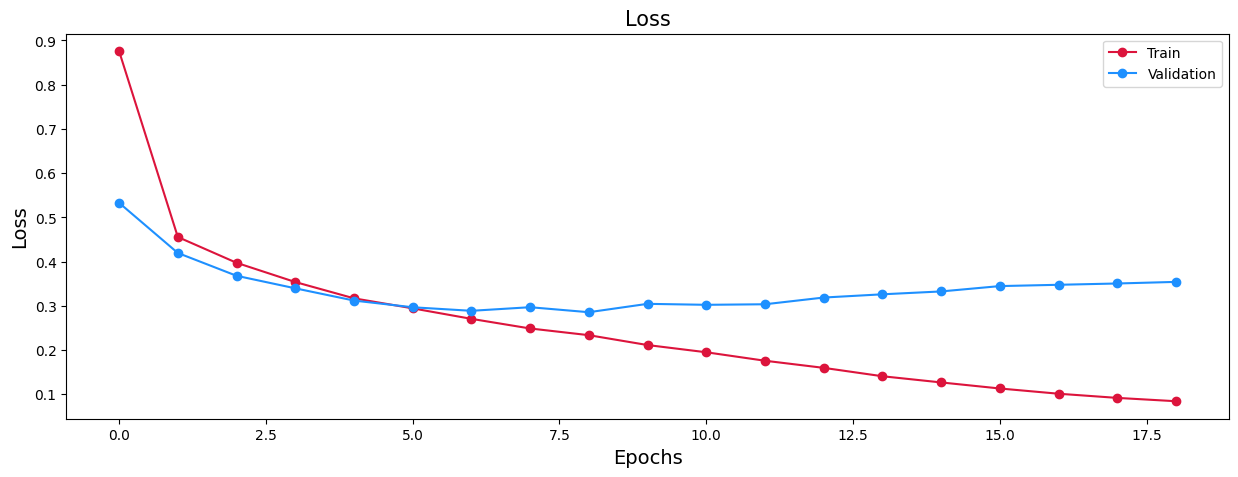

In [ ]:
plot_training_history(history)

In [ ]:
checkpoint = torch.load(best_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

test_metrics = evaluate(model, loaders["test"], criterion, device)
test_metrics

eval:   0%|          | 0/47 [00:00<?, ?it/s]

{'loss': 0.3060894142440025,
 'accuracy': np.float64(0.8982478195961342),
 'f1': 0.5068313401858358}

In [ ]:
@torch.no_grad()
def predict_dataloader(model: TransformerABSA, dataloader, device: torch.device) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_labels = []
    all_predictions = []
    for batch in tqdm(dataloader, desc="predict", leave=False):
        batch = move_batch_to_device(batch, device)
        logits = model(**model_inputs(batch))
        logits = model.reshape_logits(logits)
        predictions = logits.argmax(dim=-1)
        all_labels.append(batch["labels"].detach().cpu().numpy())
        all_predictions.append(predictions.detach().cpu().numpy())
    return np.concatenate(all_labels, axis=0), np.concatenate(all_predictions, axis=0)


y_test, y_pred = predict_dataloader(model, loaders["test"], device)
evaluator = ABSASklearnEvaluator(y_test, y_pred, aspect_category_names)
evaluator.report("aspect#category")

predict:   0%|          | 0/47 [00:00<?, ?it/s]

,precision,recall,f1-score,support
,0.931716,0.961633,0.946438,11025.000000
Cơ sở vật chất#Chất lượng,0.559633,0.500000,0.528139,122.000000
Cơ sở vật chất#Khác,0.222222,0.026667,0.047619,75.000000
Cơ sở vật chất#Không gian,0.575758,0.638655,0.605578,119.000000
Cơ sở vật chất#Vệ sinh,0.838235,0.721519,0.775510,79.000000
Nhân viên y tế#Chất lượng,0.731092,0.486034,0.583893,179.000000
Nhân viên y tế#Khác,0.625000,0.116279,0.196078,43.000000
Nhân viên y tế#Thái độ,0.871212,0.839416,0.855019,411.000000
Trải nghiệm chung#Chất lượng,0.649746,0.535565,0.587156,239.000000
Trải nghiệm chung#Giá,0.653333,0.653333,0.653333,75.000000


In [ ]:
evaluator.report("aspect#category,polarity")


,precision,recall,f1-score,support
"Cơ sở vật chất#Chất lượng,None",0.929885,0.943991,0.936885,857.000000
"Cơ sở vật chất#Chất lượng,negative",0.523810,0.239130,0.328358,46.000000
"Cơ sở vật chất#Chất lượng,neutral",1.000000,0.000000,0.000000,1.000000
"Cơ sở vật chất#Chất lượng,positive",0.511364,0.600000,0.552147,75.000000
"Cơ sở vật chất#Khác,None",0.924742,0.992257,0.957311,904.000000
"Cơ sở vật chất#Khác,negative",0.250000,0.047619,0.080000,42.000000
"Cơ sở vật chất#Khác,neutral",1.000000,0.000000,0.000000,1.000000
"Cơ sở vật chất#Khác,positive",0.000000,0.000000,0.000000,32.000000
"Cơ sở vật chất#Không gian,None",0.949233,0.934884,0.942004,860.000000
"Cơ sở vật chất#Không gian,negative",0.380952,0.470588,0.421053,51.000000


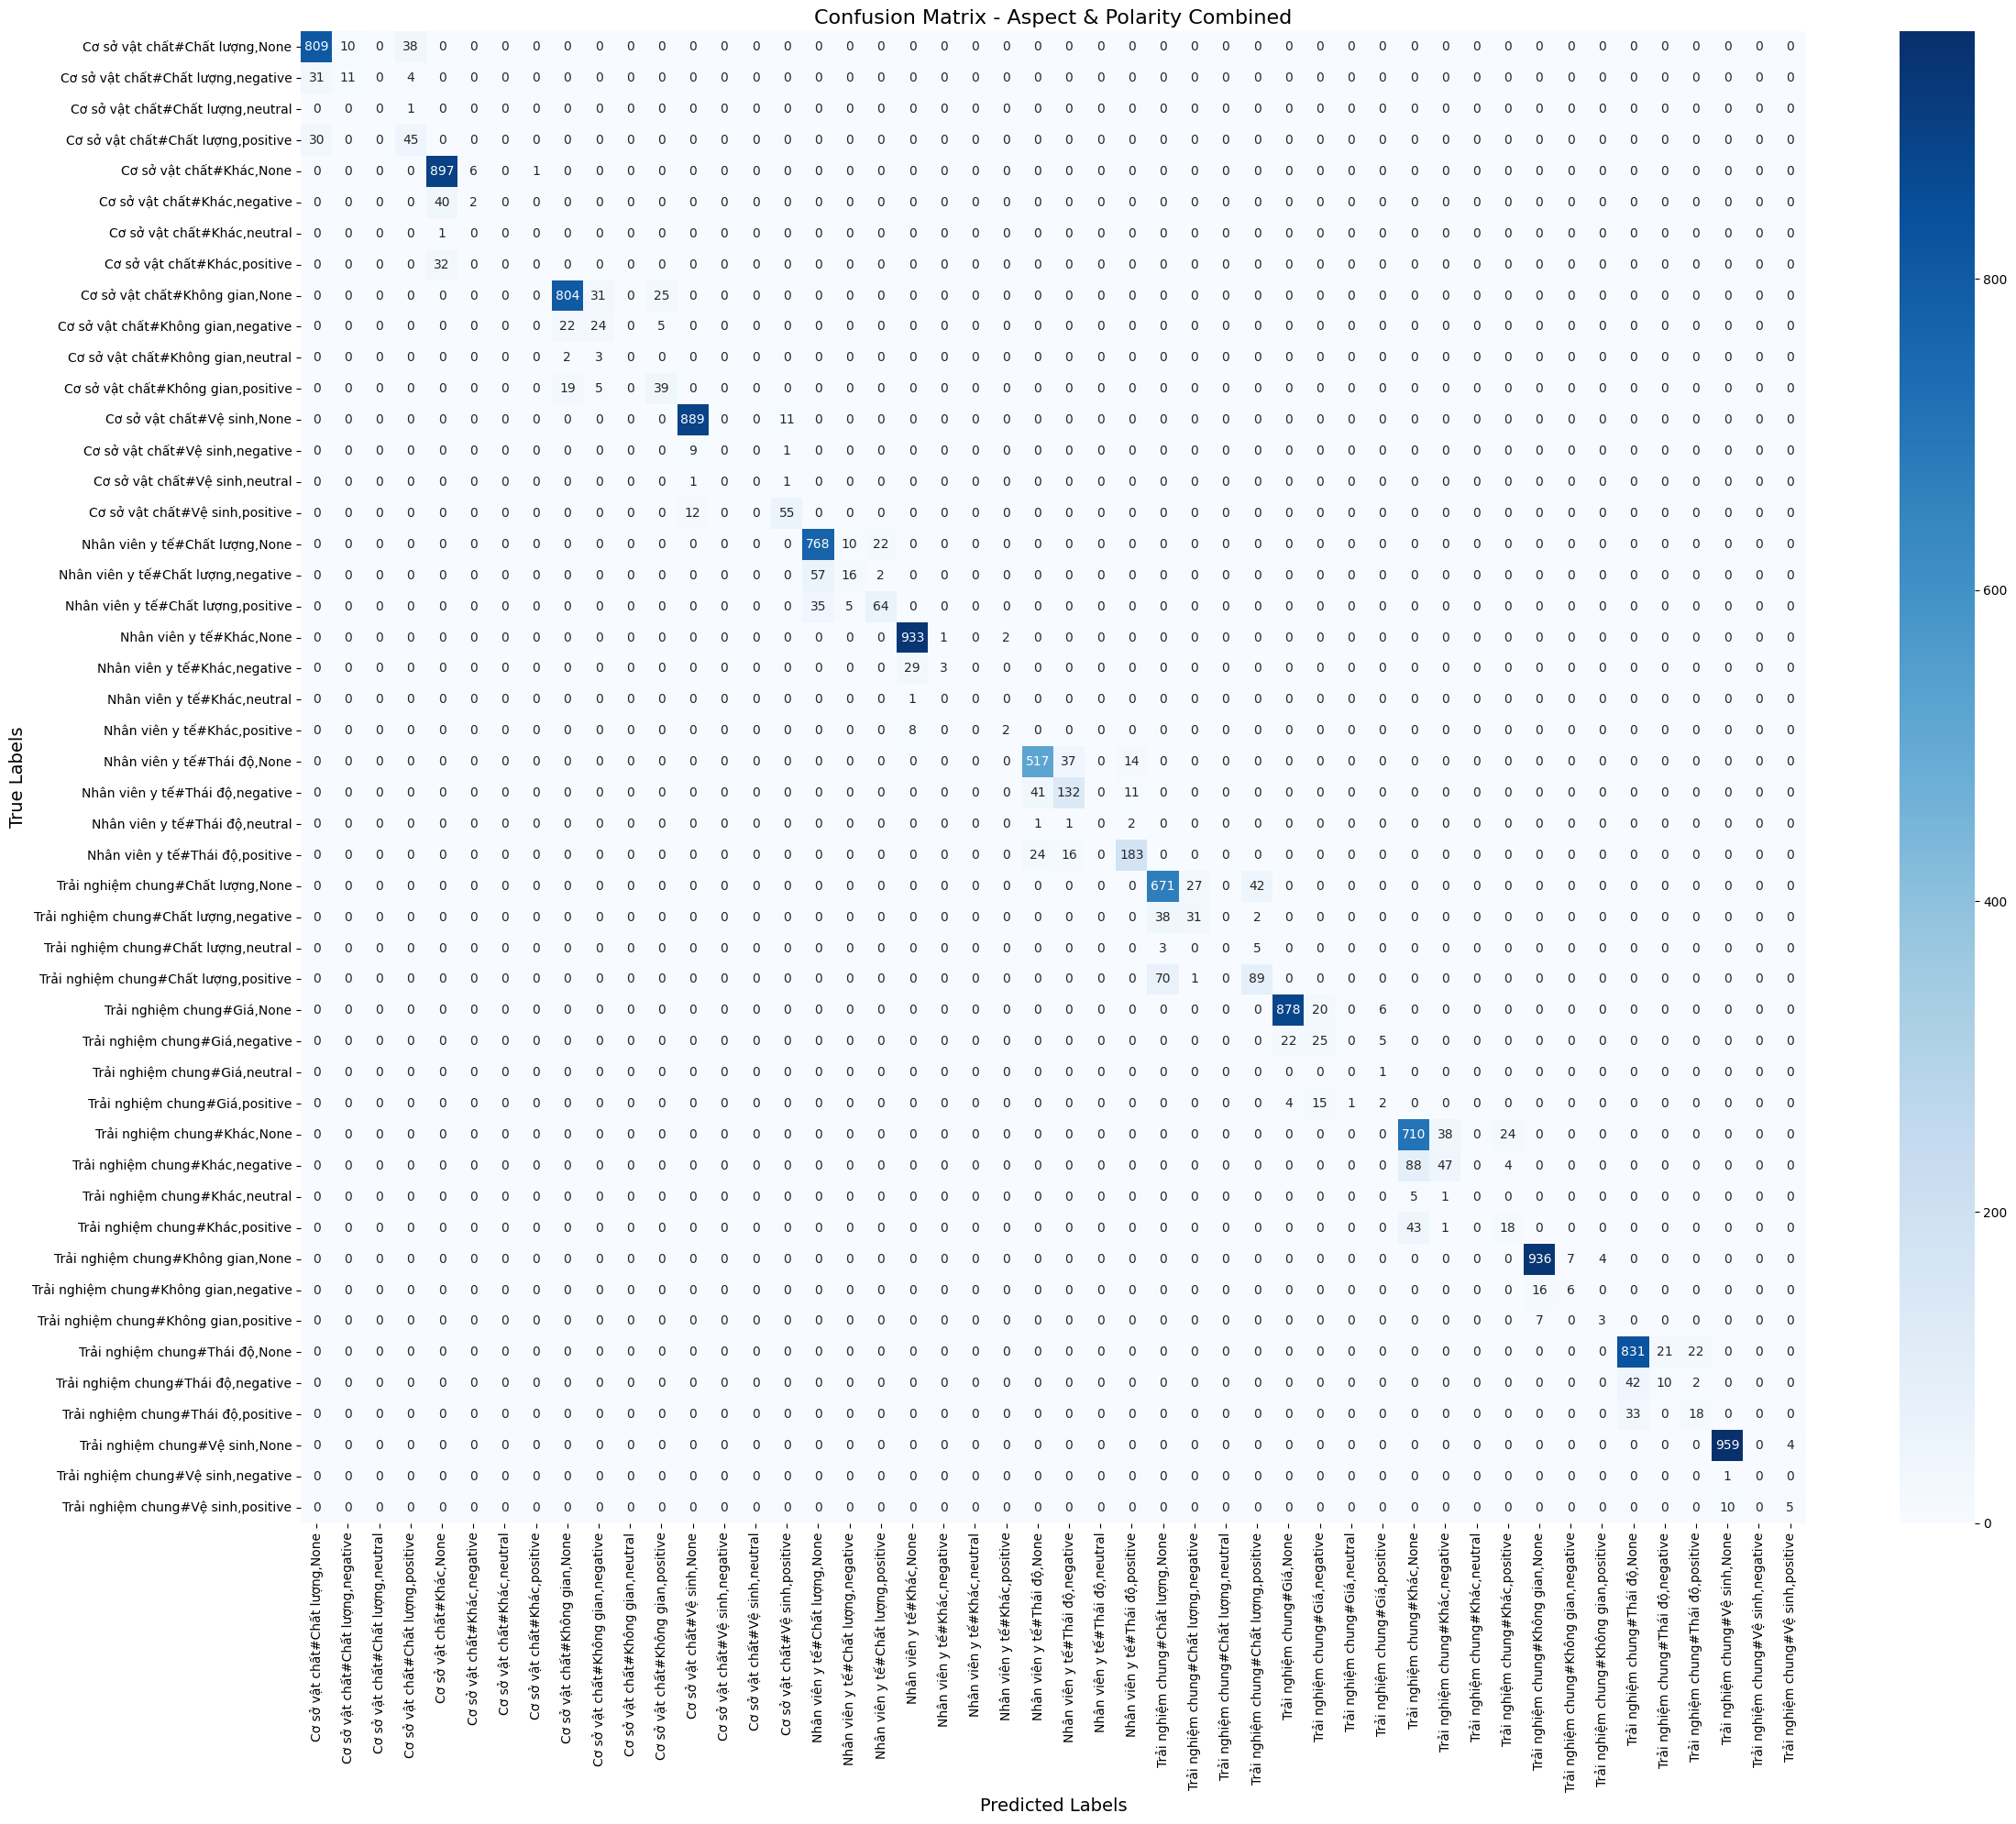

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_combined_confusion_matrix(y_test, y_pred, aspect_category_names, figsize=(24, 20)):
    y_true_str = []
    y_pred_str = []

    idx_to_polarity = {0: "None", 1: "positive", 2: "negative", 3: "neutral"}

    # Duyệt qua từng mẫu dữ liệu và từng aspect để gộp nhãn
    for row_test, row_pred in zip(y_test, y_pred):
        for index, (col_test, col_pred) in enumerate(zip(row_test, row_pred)):
            aspect_name = aspect_category_names[index]

            # Tạo nhãn kết hợp
            true_label = f"{aspect_name},{idx_to_polarity[int(col_test)]}"
            pred_label = f"{aspect_name},{idx_to_polarity[int(col_pred)]}"

            y_true_str.append(true_label)
            y_pred_str.append(pred_label)

    # Lọc lấy các nhãn thực tế có xuất hiện trong tập dữ liệu để tránh ma trận quá loãng
    unique_labels = sorted(list(set(y_true_str) | set(y_pred_str)))

    # Tính toán Confusion Matrix
    cm = confusion_matrix(y_true_str, y_pred_str, labels=unique_labels)

    # Vẽ heatmap bằng Seaborn
    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=unique_labels,
        yticklabels=unique_labels
    )
    plt.title("Confusion Matrix - Aspect & Polarity Combined", fontsize=16)
    plt.xlabel("Predicted Labels", fontsize=14)
    plt.ylabel("True Labels", fontsize=14)
    plt.xticks(rotation=90, fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()

plot_combined_confusion_matrix(y_test, y_pred, aspect_category_names)

In [ ]:
prediction_path = prediction_dir / f"{run_name}-notebook.txt"
save_absa_predictions(
    save_path=prediction_path,
    raw_texts=loaders["test"].dataset.raw_texts,
    encoded_review_labels=y_pred,
    aspect_category_names=aspect_category_names,
)
print(f"Saved predictions: {prediction_path}")


In [ ]:
@torch.no_grad()
def predict_texts(texts: str | list[str]) -> np.ndarray:
    if isinstance(texts, str):
        texts = [texts]
    model_texts = [active_text_preprocessor(text) for text in texts] if active_text_preprocessor else texts
    encoded = tokenizer(
        model_texts,
        max_length=max_length,
        padding=True,
        truncation=True,
        return_tensors="pt",
    )
    encoded = {key: value.to(device) for key, value in encoded.items()}
    logits = model(**encoded)
    logits = model.reshape_logits(logits)
    return logits.argmax(dim=-1).detach().cpu().numpy()


sample_predictions = predict_texts(["Dịch vụ rất tệ!Lúc nào cũng phải đóng tiền trước mới khám, khám bệnh nữa chừng không tới nơi tới chốn.Khám bệnh mà luôn nghĩ cách moi tiền bệnh nhân càng nhiều hơn là chữa trị.Rất thất vọng. Hy vọng ai chưa đi khám và có định đi khám thì né cái bệnh viện này."])
sample_predictions


In [ ]:
model.print_acsa_pred(torch.tensor(sample_predictions[0]))